In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from pathlib import Path
import os

# --- Configure which UMAP run to visualize ---
UMAP_FOLDER = "umaps_NN100_mindist025"  # e.g. "umaps_NN100_mindist025"

RESULTS_ROOT = Path(f"../results/{UMAP_FOLDER}")
FIGURES_DIR = Path(f"../figures/{UMAP_FOLDER}")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Best postprocessing config per model, written by visualize_postprocessing.ipynb
import yaml
with open("../configs/BEST_POSTPROC_CONFIGS.yaml") as f:
    BEST_CONFIGS = yaml.safe_load(f)

def config_stem(cfg):
    return f"{cfg['agg']}__fs{cfg['fs']}__{cfg['norm1']}__{cfg['norm2']}"

# UMAP CSV path pattern per model
MODELS = {model: f"{model}/{{cell_type}}/{config_stem(cfg)}.csv"
          for model, cfg in BEST_CONFIGS.items()}

CELL_TYPES = ["U2OS", "A549"]

# Load all data
data = {}
for model, pattern in MODELS.items():
    for ct in CELL_TYPES:
        path = RESULTS_ROOT / pattern.format(cell_type=ct)
        df = pd.read_csv(path)
        # Binary trt/control: DMSO = negcon, everything else = trt
        df["trt_control"] = np.where(df["compound"] == "DMSO", "DMSO", "treatment")
        data[(model, ct)] = df

In [2]:
def scatter_umap(ax, df, color_col, palette=None, cmap=None, order=None,
                 size_map=None, point_size=18, alpha=0.5, legend=True,
                 legend_title=None):
    """Plot a UMAP scatter on the given axes, colored by color_col."""
    x, y = df["umap_1"].values, df["umap_2"].values

    if palette is not None:
        present = set(df[color_col].dropna().unique())
        categories = order if order else sorted(present)
        # Only plot categories actually present in this subset
        categories = [c for c in categories if c in present]
        for cat in categories:
            mask = df[color_col] == cat
            s = size_map[cat] if size_map and cat in size_map else point_size
            ax.scatter(x[mask], y[mask], c=palette[cat], label=cat,
                       s=s, alpha=alpha, edgecolors="none", rasterized=True)
        if legend:
            ax.legend(markerscale=3, fontsize=7, loc="best",
                      framealpha=0.8, handletextpad=0.3,
                      title=legend_title, title_fontsize=8)
    else:
        ax.scatter(x, y, c=df[color_col], cmap=cmap,
                   s=point_size, alpha=alpha, edgecolors="none", rasterized=True)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

In [3]:
# Color palettes

# Plate: separate palette per cell type, both using full tab10 range
plates_by_ct = {}
for ct in CELL_TYPES:
    plates_by_ct[ct] = sorted({p for df in data.values()
                                if df["cell_type"].iloc[0] == ct
                                for p in df["plate"].unique()})
tab10 = plt.cm.tab10.colors
plate_palette = {}
for ct in CELL_TYPES:
    for i, p in enumerate(plates_by_ct[ct]):
        plate_palette[p] = tab10[i % 10]

# Well: continuous color based on distance from plate edge (symmetric fold)
def well_color(well):
    row_num = ord(well[0]) - 64
    col_num = int(well[1:])
    if col_num > 12: col_num = 25 - col_num
    if row_num > 8: row_num = 17 - row_num
    col_num = col_num / 12
    row_num = row_num / 8
    return 1 - (col_num * row_num) ** (1/2)

# Precompute well colors for all dataframes
for key, df in data.items():
    df["well_color"] = df["well"].apply(well_color)

# Build plate-layout reference for well color legend
cols = [str(i).zfill(2) for i in range(1, 25)]
rows = [chr(i) for i in range(65, 65 + 16)]
well_layout_colors = np.array([[well_color(r + c) for c in cols] for r in rows])

# Treatment vs control: treatment=red (small), DMSO=grey (large, on top)
trt_control_palette = {"treatment": "#d62728", "DMSO": "#b0b0b0"}
trt_control_order = ["treatment", "DMSO"]

# Timepoint: orange=24h, blue=48h
timepoint_palette = {24: "#ff7f0e", 48: "#1f77b4"}

In [4]:
# --- Top-10 MoA coloring (by max significant mAP across models) ---
from ast import literal_eval
import seaborn as sns

MAP_PER_GROUP_DIR = Path("../results/map_per_group")

# Load per-MoA mAP for all models and cell types, keep only significant
# (BEST_CONFIGS and config_stem come from cell 0)
all_moa_scores = []
for model, cfg in BEST_CONFIGS.items():
    for ct in CELL_TYPES:
        stem = config_stem(cfg)
        fname = f"{model}__{ct}__{stem}__moa.csv"
        path = MAP_PER_GROUP_DIR / fname
        if path.exists():
            df_moa = pd.read_csv(path)
            sig = df_moa[df_moa["below_corrected_p"]].copy()
            sig["model"] = model
            sig["cell_type"] = ct
            all_moa_scores.append(sig[["moas", "mean_average_precision"]])

all_moa_scores = pd.concat(all_moa_scores, ignore_index=True)

# Max significant mAP per MoA across all models and cell types
top_moas = (all_moa_scores.groupby("moas")["mean_average_precision"]
            .max()
            .nlargest(10)
            .index.tolist())
print("Top 10 MoAs (by max significant mAP across models):")
for i, m in enumerate(top_moas, 1):
    print(f"  {i}. {m}")

# 10 maximally distinct, fully saturated colors
DISTINCT_10 = [
    "#e6194b",  # red
    "#3cb44b",  # green
    "#4363d8",  # blue
    "#f58231",  # orange
    "#911eb4",  # purple
    "#42d4f4",  # cyan
    "#f032e6",  # magenta
    "#469990",  # teal
    "#e6beff",  # violet
    "#800000",  # maroon
]
moa_palette = {moa: DISTINCT_10[i] for i, moa in enumerate(top_moas)}
moa_palette["other"] = "#d0d0d0"

# Assign MoA label to each well in the UMAP data
def assign_top_moa(moas_str, top_set):
    """Return the first top-10 MoA this well belongs to, or 'other'."""
    if pd.isna(moas_str) or moas_str == "":
        return "other"
    # moas column may be a string repr of a list, or a plain string
    try:
        moa_list = literal_eval(moas_str) if moas_str.startswith("[") else [moas_str]
    except (ValueError, SyntaxError):
        moa_list = [moas_str]
    for moa in moa_list:
        if moa in top_set:
            return moa
    return "other"

top_set = set(top_moas)
for key, df in data.items():
    df["top_moa"] = df["moas"].apply(lambda x: assign_top_moa(x, top_set))

Top 10 MoAs (by max significant mAP across models):
  1. p38 MAPK inhibitor
  2. glucocorticoid receptor agonist
  3. Aurora kinase inhibitor
  4. microtubule stabilizing agent
  5. tubulin polymerization inhibitor
  6. src inhibitor
  7. ATM kinase inhibitor
  8. CHK inhibitor
  9. HSP inhibitor
  10. FLT3 inhibitor


/tmp/ipykernel_91194/4046139206.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x[mask], y[mask], c=palette[cat], label=cat,


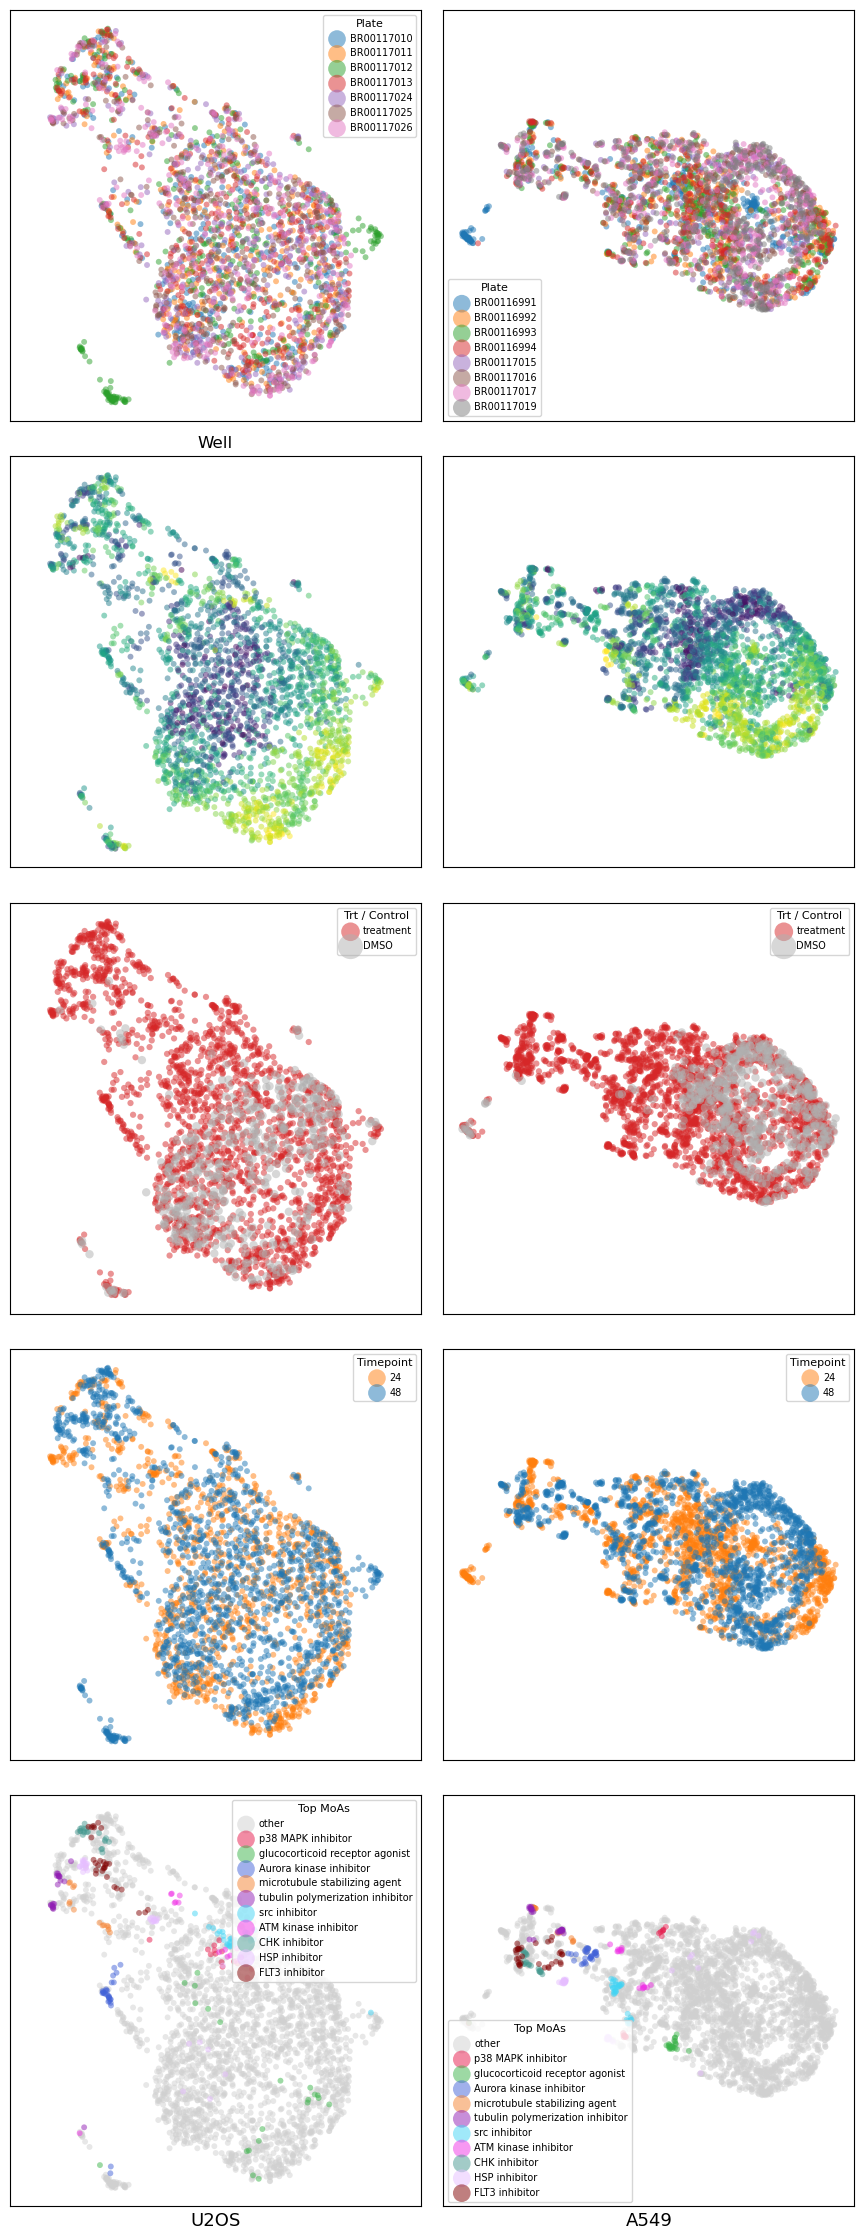

/tmp/ipykernel_91194/4046139206.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x[mask], y[mask], c=palette[cat], label=cat,


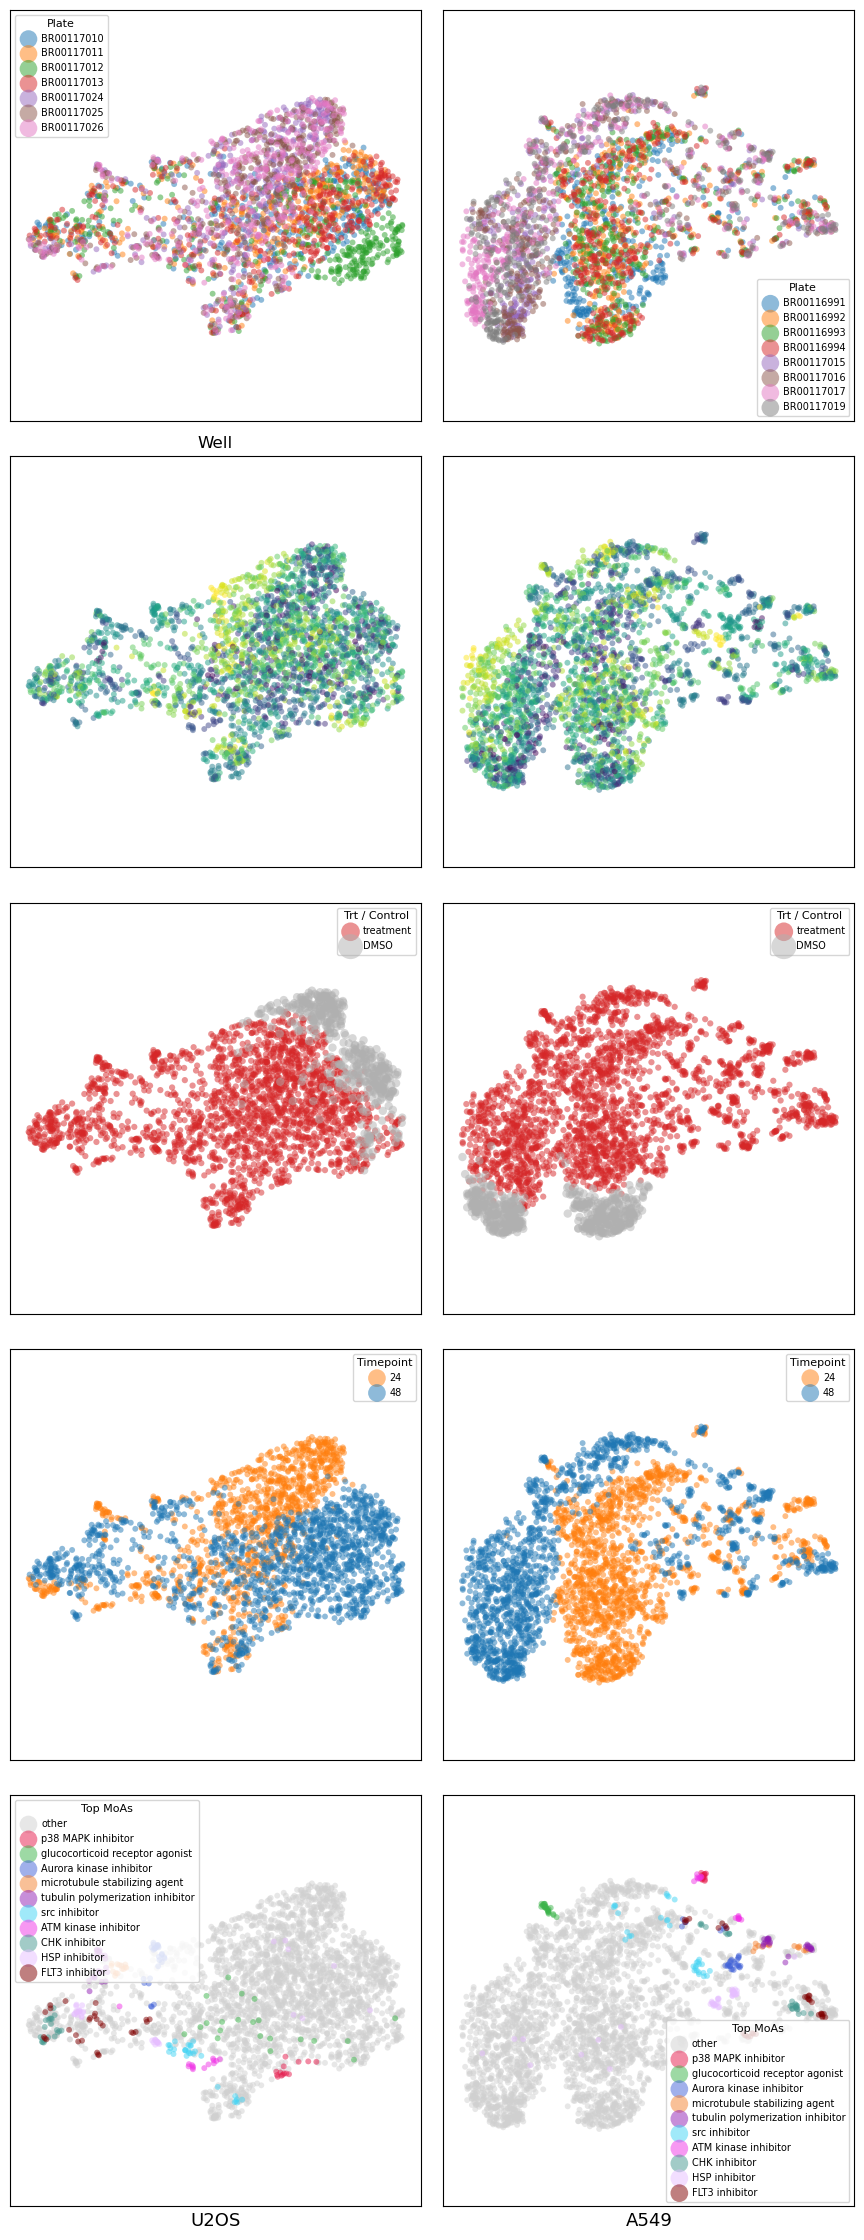

/tmp/ipykernel_91194/4046139206.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x[mask], y[mask], c=palette[cat], label=cat,


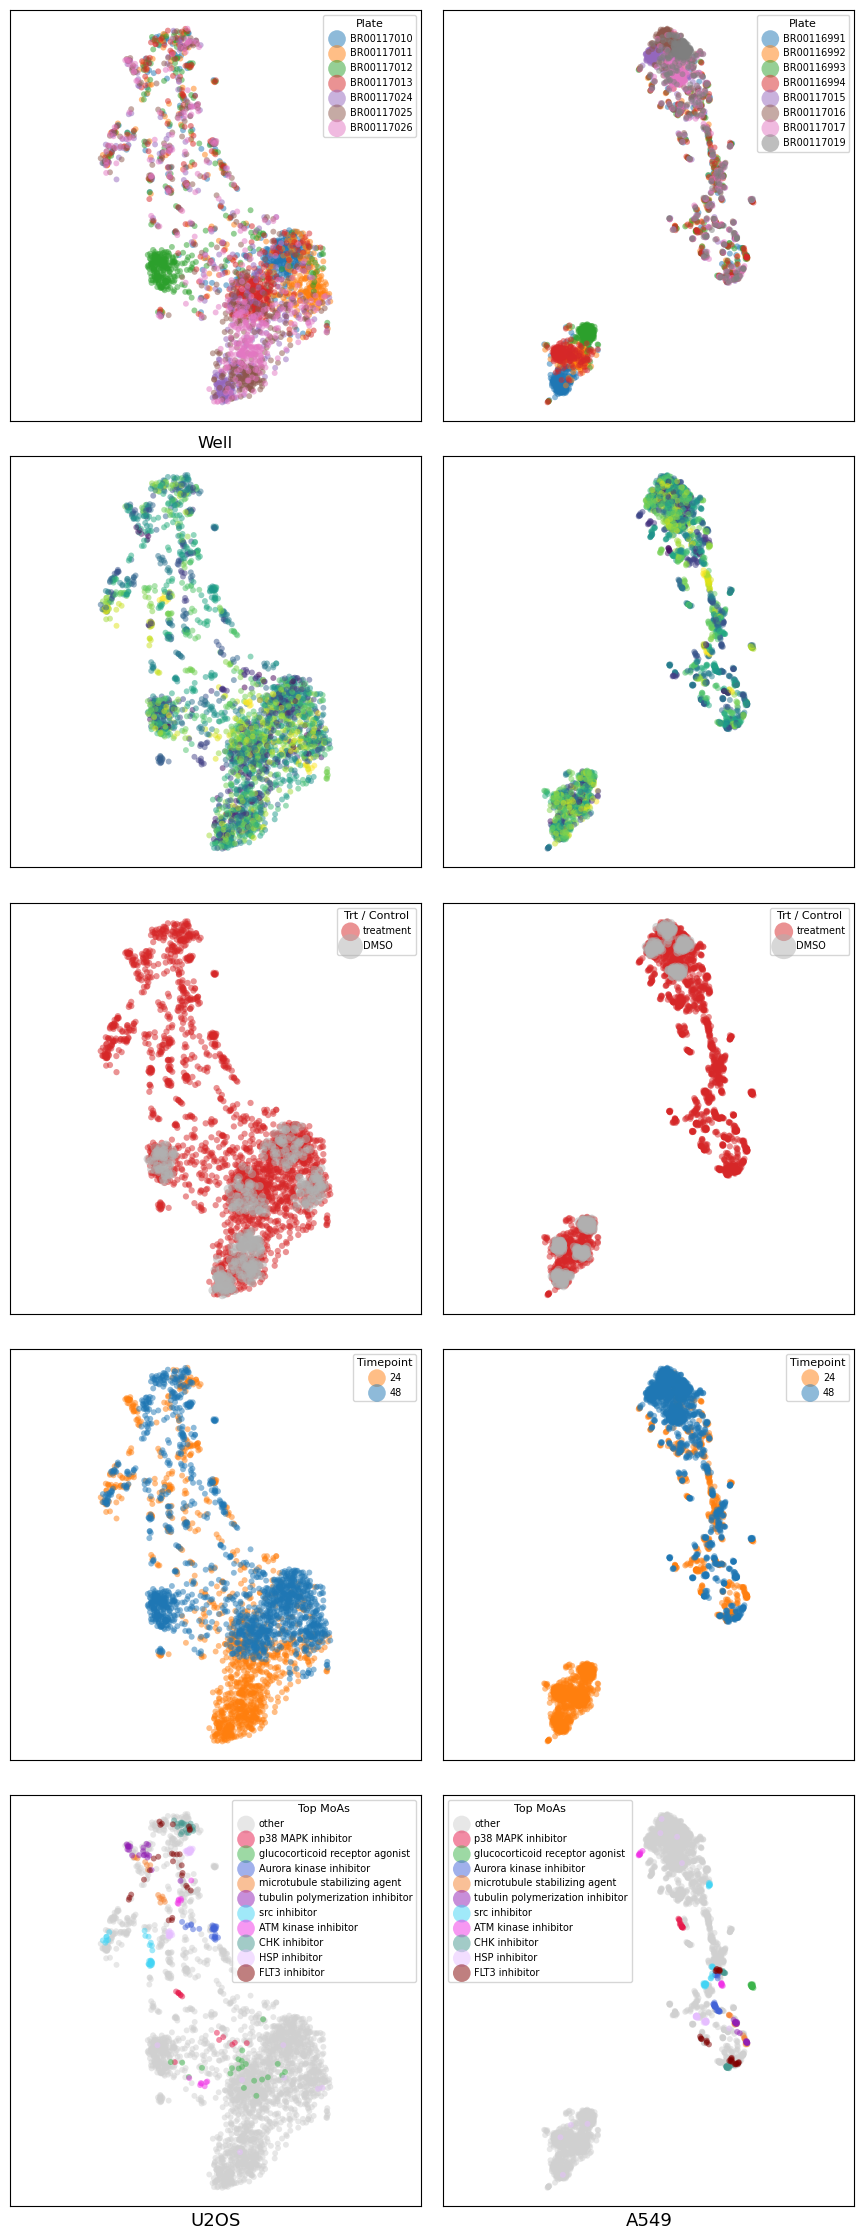

/tmp/ipykernel_91194/4046139206.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x[mask], y[mask], c=palette[cat], label=cat,


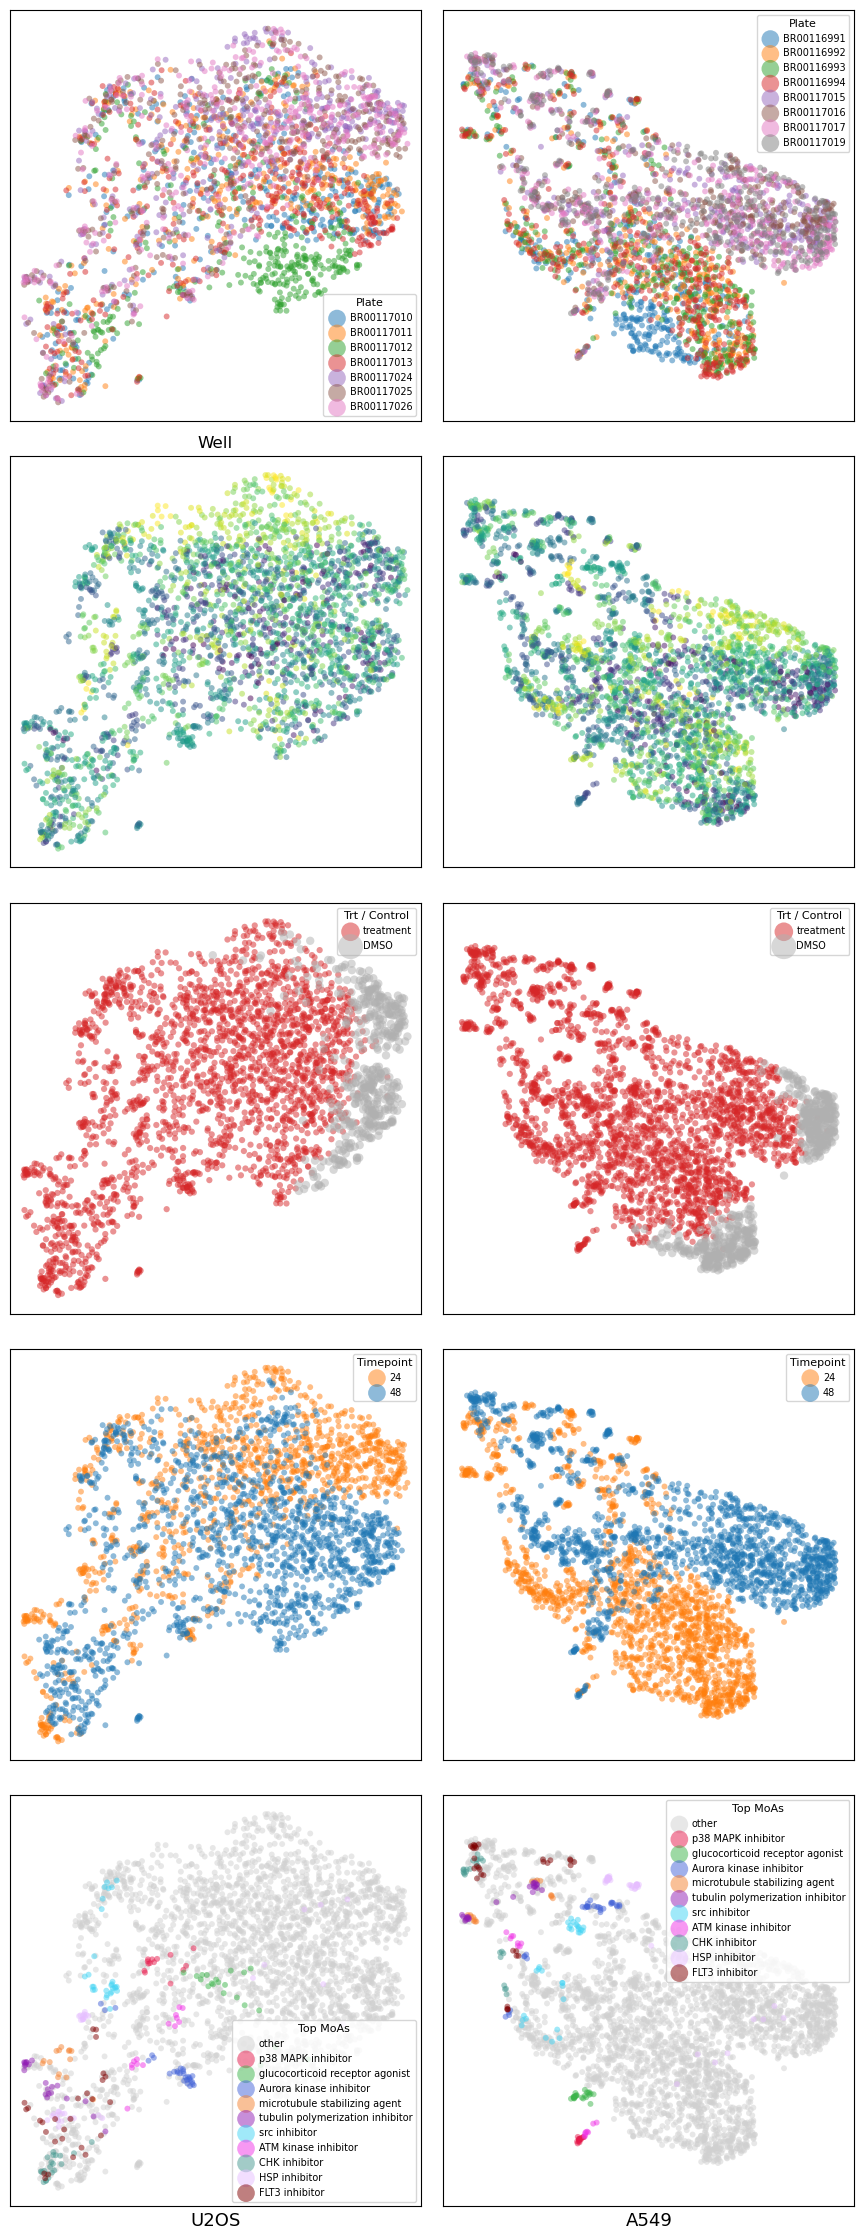

/tmp/ipykernel_91194/4046139206.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x[mask], y[mask], c=palette[cat], label=cat,


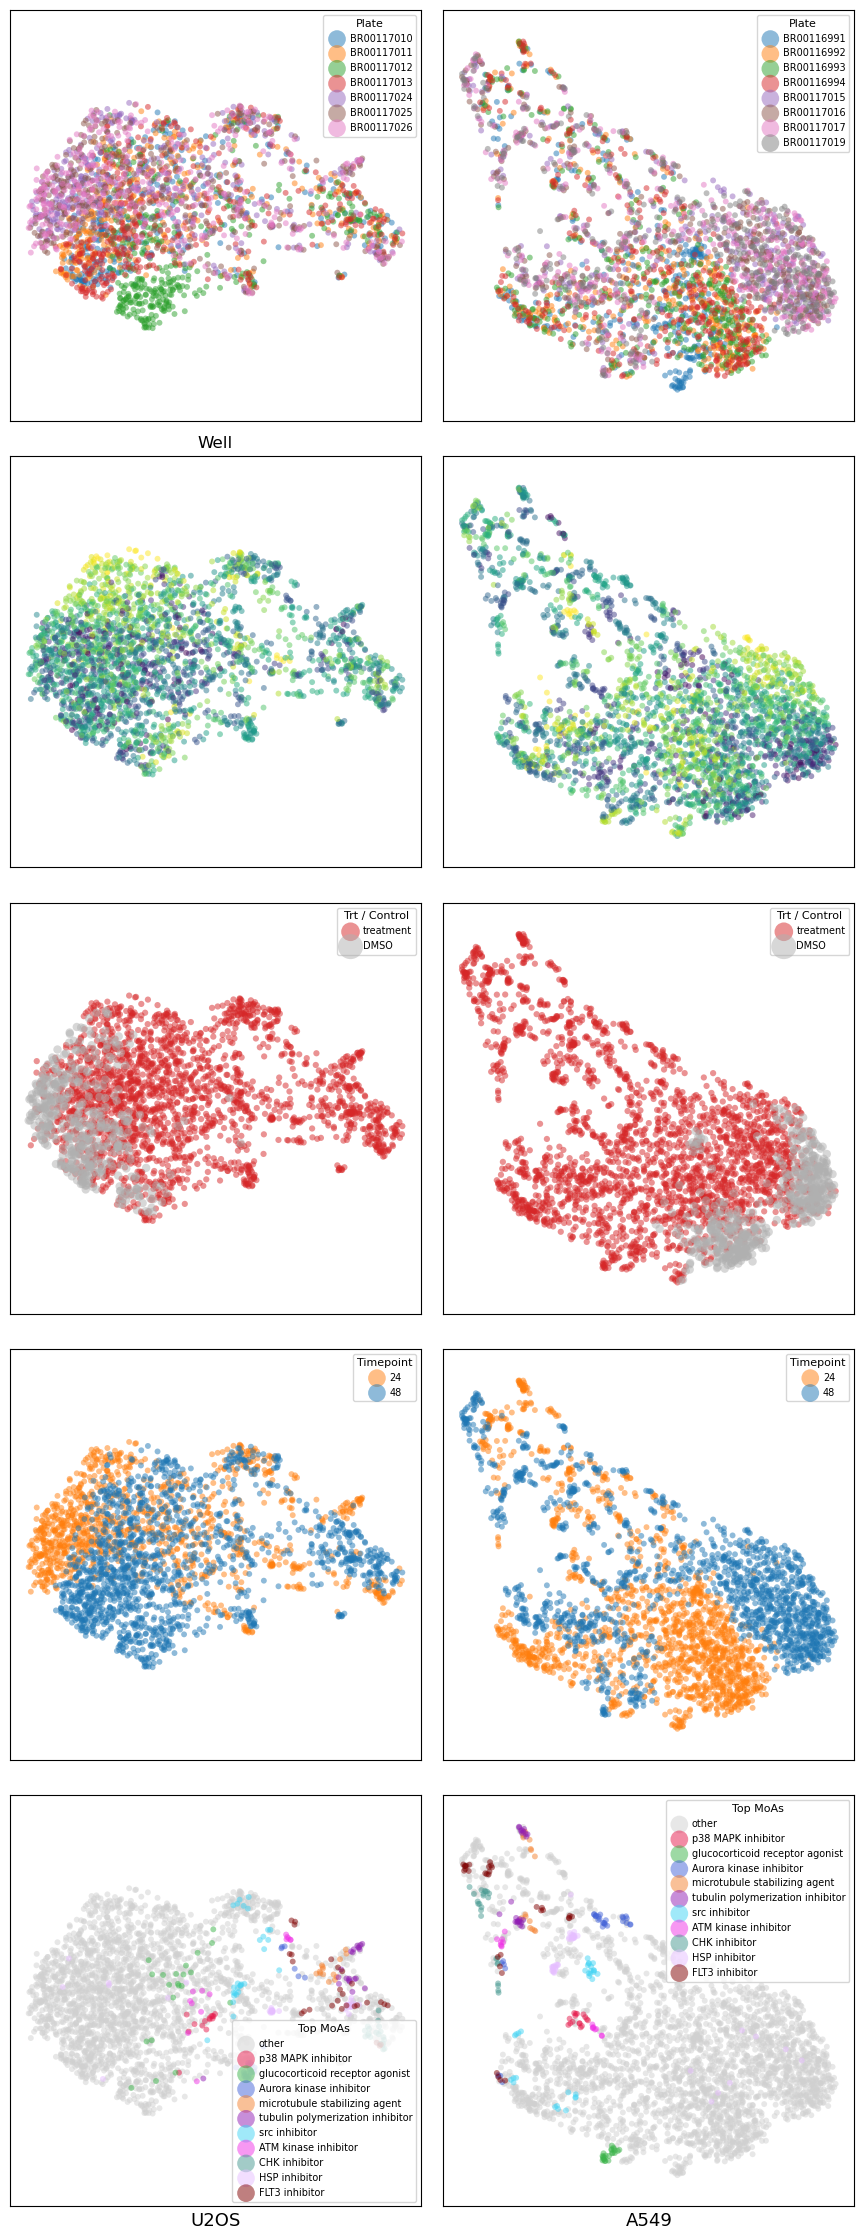

In [5]:
ROW_CONFIGS = [
    {"label": "Plate",         "col": "plate",       "palette": plate_palette,       "order": None,                 "size_map": None,                          "mode": "categorical"},
    {"label": "Well",          "col": "well_color",  "palette": None,                "order": None,                 "size_map": None,                          "mode": "continuous"},
    {"label": "Trt / Control", "col": "trt_control", "palette": trt_control_palette, "order": trt_control_order,    "size_map": {"treatment": 20, "DMSO": 36}, "mode": "categorical"},
    {"label": "Timepoint",     "col": "timepoint",   "palette": timepoint_palette,   "order": [24, 48],             "size_map": None,                          "mode": "categorical"},
    {"label": "Top MoAs",      "col": "top_moa",     "palette": moa_palette,         "order": ["other"] + top_moas, "size_map": None,                        "mode": "categorical"},
]

for model in MODELS:
    nrows = len(ROW_CONFIGS)
    ncols = len(CELL_TYPES)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows),
                             squeeze=False)

    for col_idx, ct in enumerate(CELL_TYPES):
        df = data[(model, ct)]

        for row_idx, cfg in enumerate(ROW_CONFIGS):
            ax = axes[row_idx, col_idx]

            if cfg["mode"] == "continuous":
                scatter_umap(ax, df, cfg["col"], cmap="viridis", legend=False)
            else:
                scatter_umap(ax, df, cfg["col"], palette=cfg["palette"],
                             order=cfg["order"], size_map=cfg["size_map"],
                             legend=True, legend_title=cfg["label"])

            ax.set_box_aspect(1)

            # Row label as title above the left column
            if col_idx == 0 and cfg["mode"] == "continuous":
                ax.set_title(cfg["label"], fontsize=12)

            # Cell type label on the x-axis of the last row
            if row_idx == nrows - 1:
                ax.set_xlabel(ct, fontsize=13)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"umap_{model}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

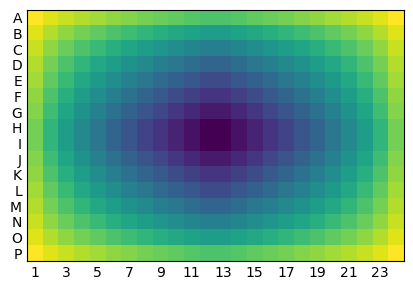

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.imshow(well_layout_colors, cmap="viridis")
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(range(1, 25, 2))
ax.set_yticks(range(16))
ax.set_yticklabels([chr(65 + i) for i in range(16)])
ax.tick_params(axis="both", length=0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "umap_well_layout_legend.pdf", dpi=300, bbox_inches="tight")
plt.show()